In [7]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import sys
import networkx as nx

from pathlib import Path


(np.float64(-64.0), np.float64(68.0), np.float64(-101.7), np.float64(67.7))

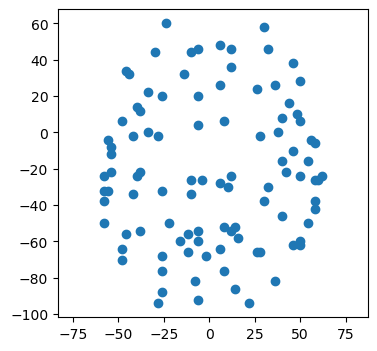

In [2]:
coords_file = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/hcp_schaefer_100/Schaefer_100_MNI_coords.txt"
coords = np.loadtxt(coords_file)[:, :3]
# coords

plt.figure(figsize=(4,4))
plt.scatter(coords[:, 0], coords[:, 1]) # 0: Left-right, 1: Anterior-posterior, 2: Inferior-superior
plt.axis('equal')


## Plotting Translucent Brain Surfaces from Above (Dorsal View)

Using `nilearn.plotting` we can plot 3D brain surfaces. By setting `view='dorsal'`, we look at the brain from above. We can make it gray and translucent using `color='gray'` and `alpha=0.3`.

- **Adult Human**: Nilearn has built-in `fsaverage` surfaces that we can download instantly.
- **Child Human & Macaque**: There are no default built-in surfaces for these in Nilearn. You will need to provide the paths to the respective `.surf.gii` (GIFTI surface) or `.obj` files that correspond to your data templates. I've mapped out exactly where you can insert those paths!
\n

[fetch_surf_fsaverage] Dataset found in /Users/adrian/nilearn_data/fsaverage


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_51198/3360111326.py:10: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(


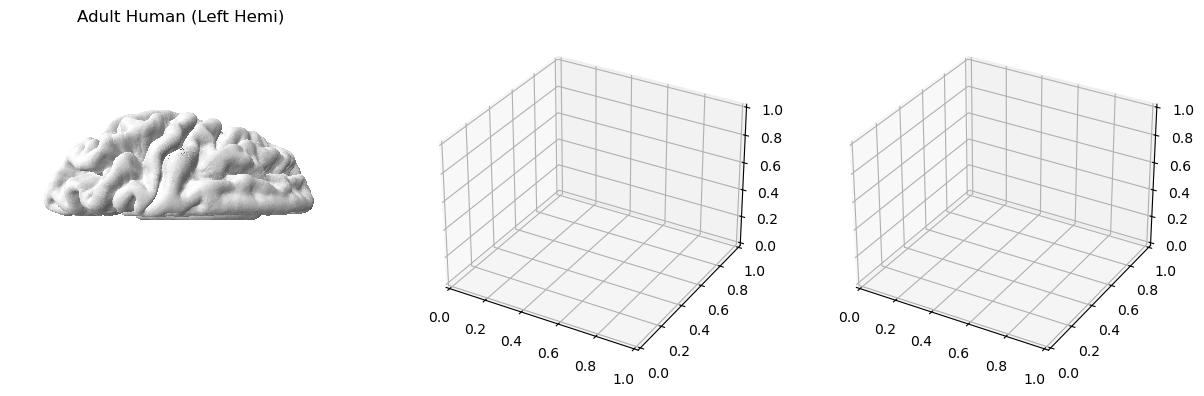

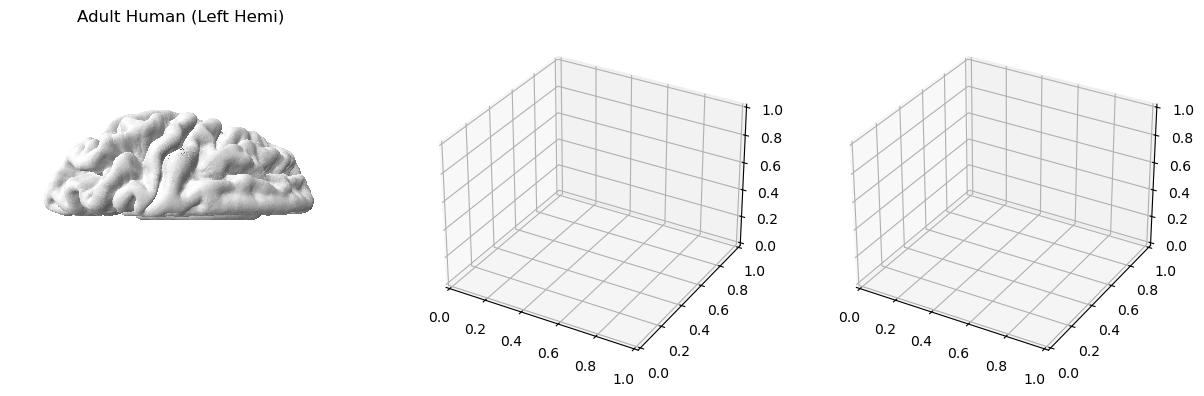

In [2]:
from nilearn import datasets, plotting
import matplotlib.pyplot as plt

# 1. Adult Human Brain (Built-in to nilearn)
fsaverage = datasets.fetch_surf_fsaverage('fsaverage')

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': '3d'})

# Plot Adult Human Brain (Left Hemisphere) from Above ('dorsal')
plotting.plot_surf(
    fsaverage.pial_left, 
    view='dorsal', 
    # color='gray', 
    alpha=0.3, 
    bg_map=fsaverage.sulc_left,
    axes=axes[0],
    title="Adult Human (Left Hemi)"
)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_51198/196230221.py:2: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf(


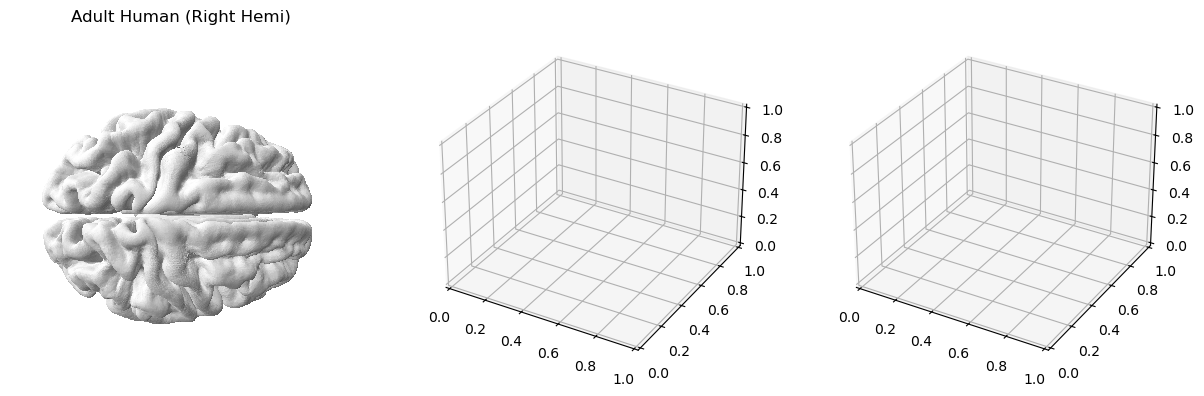

In [3]:
# Plot Adult Human Brain (Left Hemisphere) from Above ('dorsal')
plotting.plot_surf(
    fsaverage.pial_right, 
    view='dorsal', 
    # color='gray', 
    alpha=0.3, 
    bg_map=fsaverage.sulc_right,
    axes=axes[0],
    title="Adult Human (Right Hemi)"
)

In [ ]:
# 2. Child Human Brain (Requires Custom Surface File)
# UPDATE THIS PATH to your child brain surface file (e.g., from templateflow or your dataset)
child_surf_file = "path/to/child_left_hemi.surf.gii"

try:
    plotting.plot_surf(
        child_surf_file, 
        view='dorsal', 
        color='gray', 
        alpha=0.3, 
        axes=axes[1],
        title="Child Human"
    )
except ValueError:
    axes[1].set_title("Child Human\n
(Please insert valid .gii path)")
    axes[1].axis('off')

# 3. Macaque Brain (Requires Custom Surface File)
# UPDATE THIS PATH to your macaque brain surface file (e.g., NMT or F99 template)
macaque_surf_file = "path/to/macaque_left_hemi.surf.gii"

try:
    plotting.plot_surf(
        macaque_surf_file, 
        view='dorsal', 
        color='gray', 
        alpha=0.3, 
        axes=axes[2],
        title="Macaque"
    )
except ValueError:
    axes[2].set_title("Macaque\n
(Please insert valid .gii path)")
    axes[2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:

# --- Alternative approach if you just want 2D glass scattered points ---
# Nilearn has function `plot_markers` over a top-down glass brain ('z' view).
# This only works automatically for the human MNI152 template!
# coords = ... # shape (N, 3) 
# plotting.plot_markers(np.zeros(len(coords)), coords, display_mode='z', alpha=0.5)


# New attempt

In [9]:
"""
Glass Brain — Superior View with Real Pial Surfaces
=====================================================
Uses FreeSurfer fsaverage pial surface meshes (via nilearn) for the adult,
which gives actual gyral/sulcal geometry.  Child and macaque use templateflow
volumetric T1w with fine marching cubes + skull masking.

Requirements:
    pip install templateflow nibabel nilearn scikit-image scipy pyvista

Headless Linux:
    xvfb-run python glass_brain_pial.py
"""

import os
os.environ["PYVISTA_OFF_SCREEN"] = "true"

import numpy as np
import pyvista as pv
import nibabel as nib
from skimage import measure
from scipy.ndimage import gaussian_filter
import templateflow.api as tflow
from nilearn.datasets import fetch_surf_fsaverage

# ─── colour / style ──────────────────────────────────────────────────────────
GLASS_COLOUR = (0.72, 0.80, 0.92)     # pale steel-blue
BG           = (1.0, 1.0, 1.0)        # white background like the reference
WINDOW       = (3000, 1100)

# ─── 1. Adult — fsaverage pial surfaces (FreeSurfer, via nilearn) ─────────────
# fetch_surf_fsaverage downloads ~20 MB of gifti surface files once,
# then caches them.  'fsaverage' = 163k vertices/hemi; 'fsaverage5' = 10k (faster)
print("Fetching fsaverage pial surfaces …")
fsavg = fetch_surf_fsaverage('fsaverage5')   # change to 'fsaverage' for full res

def load_gifti_surf(path):
    """Return (Nx3 vertices, Mx3 faces) from a .gii surface file."""
    img = nib.load(path)
    coords = img.darrays[0].data.astype(float)   # vertices
    faces  = img.darrays[1].data.astype(int)     # triangles
    return coords, faces

lh_v, lh_f = load_gifti_surf(fsavg.pial_left)
rh_v, rh_f = load_gifti_surf(fsavg.pial_right)

def make_pv_mesh(verts, faces):
    n = len(faces)
    cells = np.hstack([np.full((n,1), 3, dtype=int), faces]).ravel()
    return pv.PolyData(verts.astype(np.float32), cells)

lh_mesh = make_pv_mesh(lh_v, lh_f)
rh_mesh = make_pv_mesh(rh_v, rh_f)

# Centre both hemispheres together
all_pts = np.vstack([lh_v, rh_v])
centre  = all_pts.mean(axis=0)
lh_mesh = lh_mesh.translate(-centre, inplace=False)
rh_mesh = rh_mesh.translate(-centre, inplace=False)
adult_meshes = [lh_mesh, rh_mesh]

# In fsaverage RAS space: X=R-L, Y=A-P, Z=S-I
# For a superior view we look straight down –Z, so we need to swap axes for
# PyVista (which uses Z-up by default).
# Rotate 90° about X so that Z_nifti → Y_pyvista (i.e. up in the viewport)
def rot_x90(mesh):
    """Rotate mesh 90° around X: (x,y,z) → (x, -z, y)"""
    m = mesh.copy()
    p = m.points.copy()
    m.points = np.column_stack([p[:,0], -p[:,2], p[:,1]])
    return m

lh_mesh_rot = rot_x90(lh_mesh)
rh_mesh_rot = rot_x90(rh_mesh)
adult_meshes_rot = [lh_mesh_rot, rh_mesh_rot]

# ─── 2. Child & Macaque — templateflow volumetric (marching cubes) ───────────
print("Fetching templateflow volumes …")

child_t1  = tflow.get('MNIPediatricAsym', cohort='2', resolution=1,
                       suffix='T1w', extension='.nii.gz')
child_mask = tflow.get('MNIPediatricAsym', cohort='2', resolution=1,
                        desc='brain', suffix='mask', extension='.nii.gz')

monkey_t1  = tflow.get('NMT31Sym', resolution=1,
                        desc='brain', suffix='T1w', extension='.nii.gz')
monkey_mask = tflow.get('NMT31Sym', resolution=1,
                         desc='brain', suffix='mask', extension='.nii.gz')

def vol_to_meshes(t1_path, mask_path, thresholds, smooth_t1=0.6, smooth_mask=1.0, step=1):
    """
    Skull-strip T1w with brain mask, extract multiple isosurfaces.
    Less smoothing = more gyral detail preserved.
    """
    t1_img   = nib.as_closest_canonical(nib.load(str(t1_path)))
    mask_img = nib.as_closest_canonical(nib.load(str(mask_path)))
    zooms    = np.array(t1_img.header.get_zooms()[:3], dtype=float)

    t1   = t1_img.get_fdata(dtype=np.float32)
    mask = mask_img.get_fdata(dtype=np.float32)

    # Skull-strip, normalise, light smooth only
    t1  = t1 * (gaussian_filter(mask, smooth_mask) > 0.5)
    mn, mx = t1[t1 > 0].min(), t1.max()
    t1  = np.clip((t1 - mn) / (mx - mn), 0, 1)
    t1  = gaussian_filter(t1, sigma=smooth_t1)

    meshes = []
    for thr in thresholds:
        try:
            verts, faces, _, _ = measure.marching_cubes(
                t1, level=thr, step_size=step, spacing=zooms)
            n = len(faces)
            cells = np.hstack([np.full((n,1),3,dtype=int), faces]).ravel()
            m = pv.PolyData(verts.astype(np.float32), cells)
            m = m.clean()
            # Very light smoothing — preserve folds, just remove staircase artefacts
            m = m.smooth(n_iter=15, relaxation_factor=0.05)
            meshes.append(m)
        except Exception as e:
            print(f"  skipping threshold {thr}: {e}")
    return meshes, zooms

print("Extracting child surface …")
child_meshes_raw, _ = vol_to_meshes(
    child_t1, child_mask,
    thresholds=[0.18, 0.30, 0.44, 0.58],
    smooth_t1=0.8, step=1
)

print("Extracting macaque surface …")
monkey_meshes_raw, _ = vol_to_meshes(
    monkey_t1, monkey_mask,
    thresholds=[0.18, 0.30, 0.46, 0.62],
    smooth_t1=0.6, step=1
)

def centre_meshes(mesh_list):
    if not mesh_list:
        return mesh_list
    pts = mesh_list[-1].points
    c   = pts.mean(axis=0)
    return [m.translate(-c, inplace=False) for m in mesh_list]

child_meshes_raw  = centre_meshes(child_meshes_raw)
monkey_meshes_raw = centre_meshes(monkey_meshes_raw)

# Volumetric templates are already in RAS-like space but need the same rot
child_meshes_rot  = [rot_x90(m) for m in child_meshes_raw]
monkey_meshes_rot = [rot_x90(m) for m in monkey_meshes_raw]

# ─── 3. Layout — spread brains along X ───────────────────────────────────────

def x_width(meshes):
    if not meshes:
        return 80
    b = meshes[-1].bounds   # (xmin, xmax, ymin, ymax, zmin, zmax)
    return b[1] - b[0]

GAP = 40   # mm between panels
w_adult  = x_width(adult_meshes_rot)
w_child  = x_width(child_meshes_rot)
w_monkey = x_width(monkey_meshes_rot)

x_adult  = 0
x_child  = -(w_adult/2 + GAP + w_child/2)
x_monkey =  (w_adult/2 + GAP + w_monkey/2)

def shift_x(meshes, dx):
    return [m.translate([dx,0,0], inplace=False) for m in meshes]

adult_final  = shift_x(adult_meshes_rot,  x_adult)
child_final  = shift_x(child_meshes_rot,  x_child)
monkey_final = shift_x(monkey_meshes_rot, x_monkey)

# ─── 4. Render ────────────────────────────────────────────────────────────────
print("Rendering …")

pl = pv.Plotter(off_screen=True, window_size=WINDOW)
pl.set_background(BG)

# Adult: two hemispheres, two passes (inner + outer) for depth effect
ADULT_OPS   = [0.12, 0.12]   # [lh, rh] — they naturally overlap at midline
CHILD_OPS   = [0.08, 0.12, 0.16, 0.20]
MONKEY_OPS  = [0.08, 0.12, 0.18, 0.24]

def add_meshes(plotter, meshes, opacities, color):
    for mesh, op in zip(meshes, opacities):
        plotter.add_mesh(
            mesh,
            color=color,
            opacity=op,
            smooth_shading=True,
            specular=0.8,
            specular_power=80,
            ambient=0.25,
            diffuse=0.8,
            pbr=False,
        )

add_meshes(pl, adult_final,  ADULT_OPS,  GLASS_COLOUR)
add_meshes(pl, child_final,  CHILD_OPS,  GLASS_COLOUR)
add_meshes(pl, monkey_final, MONKEY_OPS, GLASS_COLOUR)

# ─── Camera: look straight down (–Y after rotation = superior) ───────────────
# After rot_x90, the brain's superior surface faces +Y in PyVista space.
# We position camera at +Y looking toward origin, with nose pointing +Z (anterior)
pl.camera.position    = (0,  600, 0)
pl.camera.focal_point = (0,    0, 0)
pl.camera.up          = (0,    0, 1)   # anterior = up in the image
pl.camera.zoom(1.05)

# ─── Lighting ─────────────────────────────────────────────────────────────────
pl.remove_all_lights()
# Soft overhead key light
light1 = pv.Light(position=(0, 800, 400), color='white', intensity=0.9)
light1.positional = True
pl.add_light(light1)
# Gentle fill from front
light2 = pv.Light(position=(0, 200, 600), color='white', intensity=0.4)
light2.positional = True
pl.add_light(light2)


Fetching fsaverage pial surfaces …
Fetching templateflow volumes …
Extracting child surface …
Extracting macaque surface …
Rendering …


In [10]:

# ─── Labels ──────────────────────────────────────────────────────────────────
label_style = dict(font_size=20, color='#2a3a52') # , bold=True)
sub_style   = dict(font_size=12, color='#6070a0')

pl.add_text("Adult Human",    position=(0.18, 0.92), viewport=True, **label_style)
pl.add_text("fsaverage pial", position=(0.16, 0.87), viewport=True, **sub_style)

pl.add_text("Child (~6 yr)",            position=(0.46, 0.92), viewport=True, **label_style)
pl.add_text("MNIPediatricAsym cohort-2", position=(0.41, 0.87), viewport=True, **sub_style)

pl.add_text("Rhesus Macaque", position=(0.76, 0.92), viewport=True, **label_style)
pl.add_text("NMT31Sym",       position=(0.79, 0.87), viewport=True, **sub_style)

pl.add_text(
    "Brain Morphology Across Species & Development  ·  Superior View",
    position=(0.5, 0.97), viewport=True, font_size=16,
    color='#1a2a40', #  bold=True,
)
pl.add_text(
    "templateflow.org  |  nilearn fsaverage",
    position=(0.5, 0.01), viewport=True, font_size=10, color='#aabbcc',
)

out = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/brains_from_above") / "glass_brain_pial.png"
pl.screenshot(out, transparent_background=True)
pl.close()
print(f"\nSaved → {out}")


Saved → /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/brains_from_above/glass_brain_pial.png
